In [1]:
# importing required libraries

!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("/content/Daily Climate Train.csv")

In [ ]:
df.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


<Axes: >

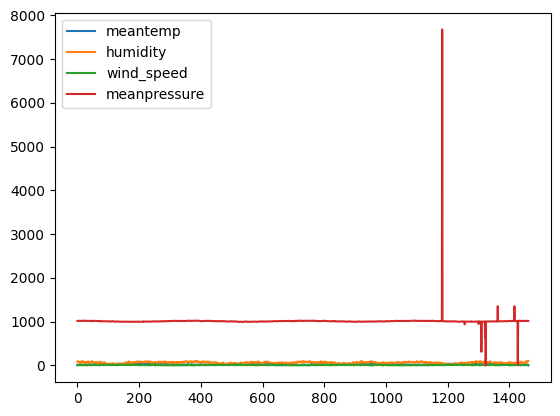

In [3]:
df.plot()

In [5]:
df = df[['date', 'meantemp']]
df.columns = ['ds','y']
df.head()

,ds,y
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [6]:
df['ds'] = pd.to_datetime(df['ds'])

/tmp/ipykernel_1119/3173280147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = pd.to_datetime(df['ds'])


In [7]:
df.head()

,ds,y
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [20]:
df.tail()

,ds,y
1457,2016-12-28,17.217391
1458,2016-12-29,15.238095
1459,2016-12-30,14.095238
1460,2016-12-31,15.052632
1461,2017-01-01,10.000000


In [8]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [9]:
# Initialize the Model
model=Prophet()

In [10]:
df.columns

Index(['ds', 'y'], dtype='object')

In [11]:
df.dropna(axis=0,inplace=True)
df.head()

/tmp/ipykernel_1119/2384546804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0,inplace=True)


,ds,y
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [12]:
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df.dropna(inplace=True)
model.fit(df)

/tmp/ipykernel_1119/1267480599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y'] = pd.to_numeric(df['y'], errors='coerce')
/tmp/ipykernel_1119/1267480599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [13]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [14]:
# Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [15]:
future_dates.tail()

,ds
1822,2017-12-28
1823,2017-12-29
1824,2017-12-30
1825,2017-12-31
1826,2018-01-01


In [16]:
prediction=model.predict(future_dates)

In [17]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,24.690062,9.188884,14.304112,24.690062,24.690062,-12.939164,-12.939164,-12.939164,0.034028,0.034028,0.034028,-12.973191,-12.973191,-12.973191,0.0,0.0,0.0,11.750898
1,2013-01-02,24.690224,9.267017,14.296687,24.690224,24.690224,-12.803802,-12.803802,-12.803802,0.146257,0.146257,0.146257,-12.950059,-12.950059,-12.950059,0.0,0.0,0.0,11.886422
2,2013-01-03,24.690387,9.321154,14.551526,24.690387,24.690387,-12.844533,-12.844533,-12.844533,0.067150,0.067150,0.067150,-12.911683,-12.911683,-12.911683,0.0,0.0,0.0,11.845854
3,2013-01-04,24.690550,9.244862,14.545982,24.690550,24.690550,-12.832477,-12.832477,-12.832477,0.027528,0.027528,0.027528,-12.860005,-12.860005,-12.860005,0.0,0.0,0.0,11.858073
4,2013-01-05,24.690713,9.453328,14.403717,24.690713,24.690713,-12.866139,-12.866139,-12.866139,-0.069126,-0.069126,-0.069126,-12.797013,-12.797013,-12.797013,0.0,0.0,0.0,11.824573


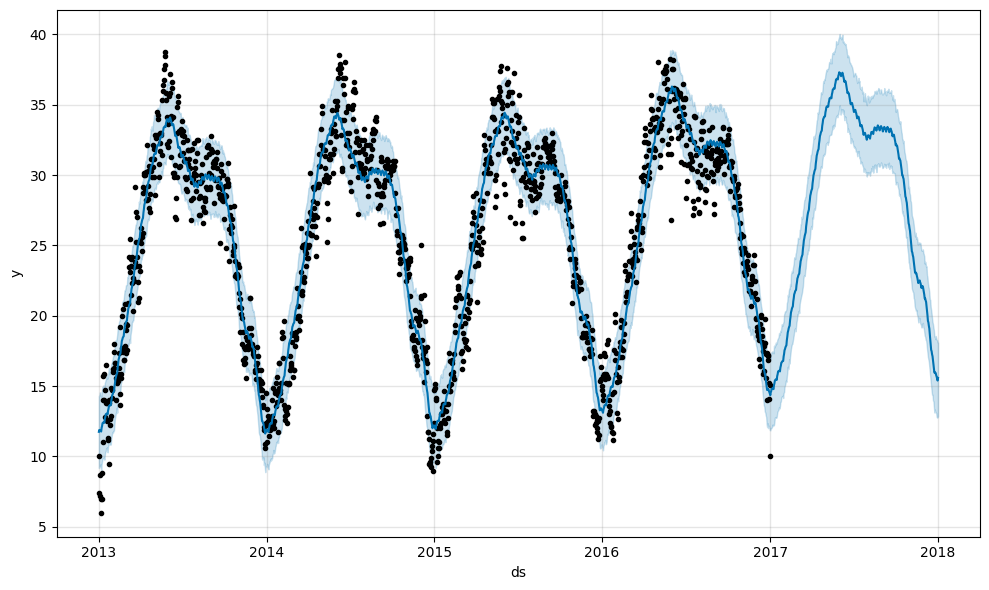

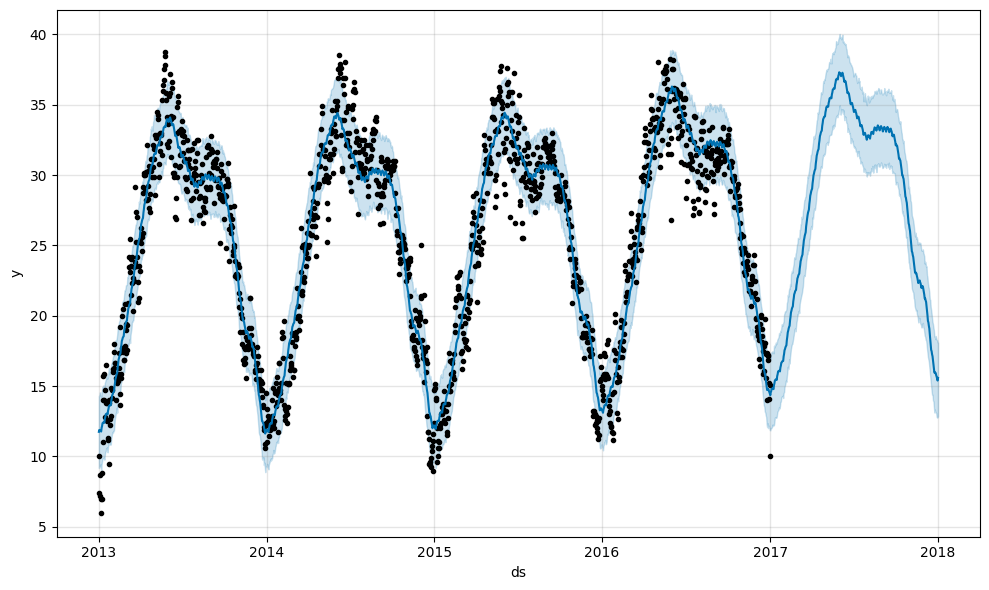

In [18]:
# plot the predicted projection
model.plot(prediction)

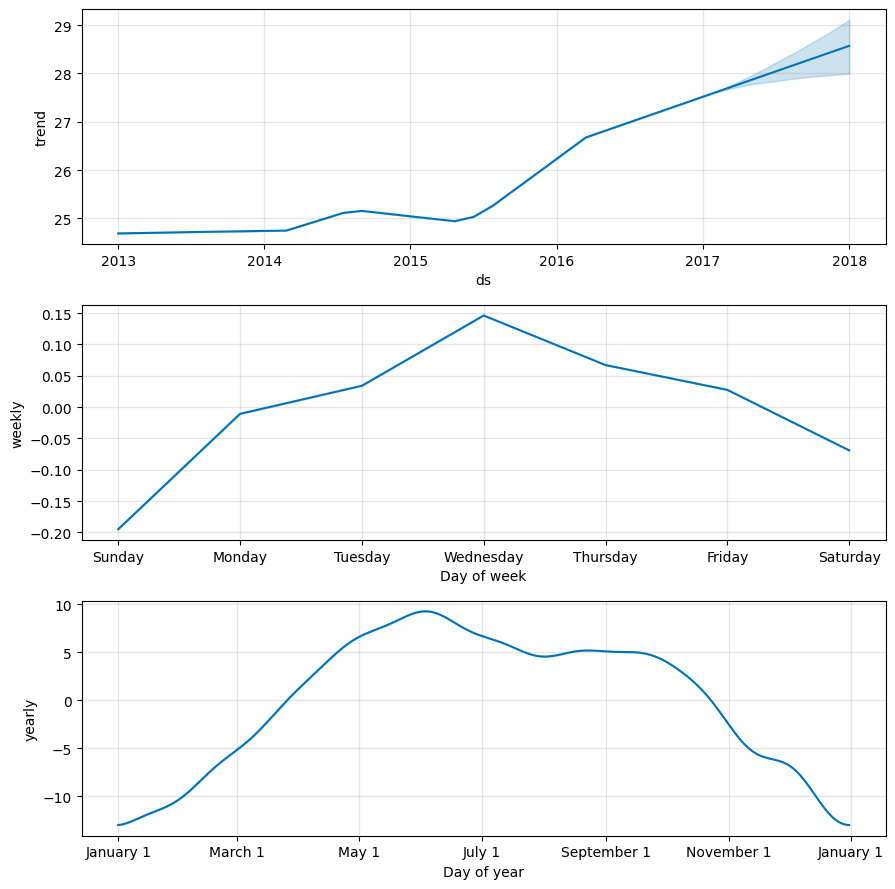

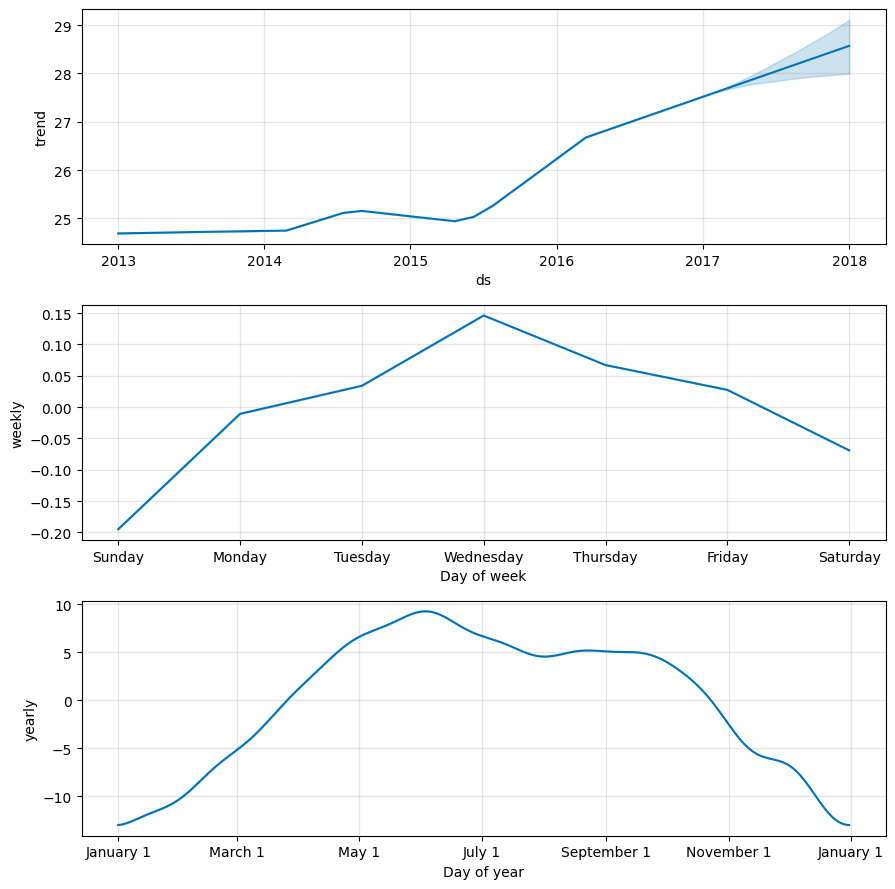

In [19]:
# Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [21]:
#Time Series Analysis

2013-17
#Cross Validation
2013-16 #Train dataset
2016-17 #Test dataset
2017-18 #Validation

1999

In [22]:
df.head()

,ds,y
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [23]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 3 forecasts with cutoffs between 2015-01-07 00:00:00 and 2016-01-02 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-08,12.371727,9.675757,14.745958,10.000,2015-01-07
1,2015-01-09,12.432036,10.069515,15.086484,10.625,2015-01-07
2,2015-01-10,12.630032,10.090926,15.131069,11.125,2015-01-07
3,2015-01-11,12.753647,10.181501,15.212581,11.000,2015-01-07
4,2015-01-12,13.260087,10.780957,15.585502,10.625,2015-01-07


In [24]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)

In [25]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,5.798027,2.407909,1.871573,0.112701,0.076104,0.111299,0.718654
1,38 days,5.689194,2.385203,1.850204,0.110541,0.069593,0.109223,0.721713
2,39 days,5.551631,2.356190,1.815403,0.108188,0.069593,0.106806,0.737003
3,40 days,5.348745,2.312735,1.794891,0.106396,0.069593,0.105093,0.737003
4,41 days,4.930436,2.220459,1.746231,0.102992,0.069593,0.101937,0.752294


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


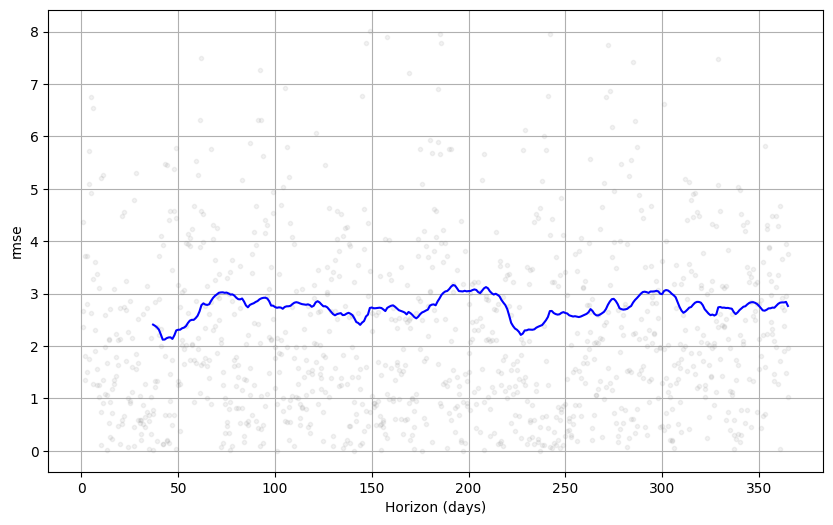

In [26]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')